# Analisi Regex Classification vs Etichette Originali

**Obiettivo**: Confrontare una classificazione basata su regex pattern (termini AI italiano/inglese) con le etichette originali nel dataset `ai_records_export_classificata.csv`.

**Output Atteso**:
- Metriche confusione: TP, TN, FP, FN, Accuracy, Precision, Recall, F1-Score
- Confusion Matrix visualizzata
- Top-20 esempi per categoria (TP, TN, FP, FN)
- Distribution plot originale vs predetta

In [27]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
from pathlib import Path

# Configurazione stili
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 100

print("Librerie caricate correttamente.")

Librerie caricate correttamente.


## 1. Caricamento Dataset

In [28]:
# Definizione path (notebook è in notebooks/dataset_prep, quindi salire di 2 livelli)
data_path = Path('../../data/distilled/ai_records_export_classificata.csv')

# Caricamento dataset
df = pd.read_csv(data_path)

print(f"Dataset caricato: {df.shape[0]} righe, {df.shape[1]} colonne")
print(f"\nNomi colonne: {list(df.columns)}")
print(f"\nPrime righe:")
display(df.head(10))

print(f"\nDistribuzione etichette originali:")
print(df['Label'].value_counts())
print(f"\nPercentuali:")
print(df['Label'].value_counts(normalize=True) * 100)

Dataset caricato: 8020 righe, 2 colonne

Nomi colonne: ['Descrizione', 'Label']

Prime righe:


,Descrizione,Label
0,Concessione di agevolazioni sotto forma di ese...,non_ai
1,Sostegno al'accesso al credito per finanziamen...,non_ai
2,Concessione di agevolazioni sotto forma di ese...,non_ai
3,Concessione di agevolazioni sotto forma di ese...,non_ai
4,Concessione di agevolazioni sotto forma di ese...,non_ai
5,Concessione di agevolazioni sotto forma di ese...,non_ai
6,ALGORITMO RYLER,non_ai
7,SVILUPPO DI UNA PROCEDURA AUTOMATIZZATA DI CAL...,ai
8,L Italia che ti sorprende,non_ai
9,Machine Learning Solutions,non_ai



Distribuzione etichette originali:
Label
non_ai    4594
ai        3426
Name: count, dtype: int64

Percentuali:
Label
non_ai    57.281796
ai        42.718204
Name: proportion, dtype: float64


## 2. Definizione Regex Patterns AI (Italiano + Inglese)

In [29]:
# Definizione whitelist conservativa di termini AI
ai_keywords = [
    # INGLESE - Core ML/AI terms
    r'\bartificial\s+intelligence\b', r'\bai\b(?![\w])', r'\bmachine\s+learning\b', r'\bml\b(?![\w])',
    r'\bdeep\s+learning\b', r'\bneural\s+network[s]?\b', r'\bnlp\b', r'\bnatural\s+language\b',
    r'\bcomputer\s+vision\b', r'\bcv\b(?![\w])', r'\breinforcement\s+learning\b',
    r'\blarge\s+language\s+model[s]?\b', r'\bllm[s]?\b', r'\bgenerative\s+ai\b',
    r'\btransformer[s]?\b', r'\bbert\b', r'\bgpt\b', r'\bconv[o]?lutional\s+neural\b',
    r'\bcnn[s]?\b', r'\brnn[s]?\b', r'\blstm\b', r'\bgan[s]?\b',
    r'\bvision\s+transformer\b', r'\bvit\b', r'\btraditional\s+language\s+model\b',
    r'\bgenerat(?:ive|ing)\s+model[s]?\b', r'\bautoencod(?:er|ing|ers)\b',
    r'\bvariation(?:al)?\s+autoencod\b', r'\bvae[s]?\b', r'\bembedding[s]?\b',
    r'\bword2vec\b', r'\bskip-?gram\b', r'\bglove\b', r'\bfasttext\b',
    
    # ITALIANO - Termini AI
    r'\b(?:intelligenza|inteligenza)\s+artificial[e]?\b', r'\b(?:reti|rete)\s+neural[i]?\b',
    r'\bapprendimento\s+(?:automatico|automata|machine|profondo|profonda)\b',
    r'\bvisione\s+artificial[e]?\b', r'\bvisione\s+(?:su\s+)?computer\b',
    r'\b(?:algoritmi|algoritmo)\s+(?:intelligen|machine|learning|neurale)\b',
    r'\bclassificazione\s+(?:automatica|intelligente)\b', r'\bdetection\s+(?:automatico|intelligente)\b',
    r'\bsegmentazione\s+(?:automatica|intelligente|semantica)\b',
    r'\bautomazione\s+intelligente\b', r'\bprocesso\s+(?:automato|automatico|automazione)\b',
    r'\blarge\s+language\s+model\b', r'\bllm\b',
    r'\bpredittiv[o|a|i|e]\b.*(?:model|sistema|algoritmo|rete)\b', 
    r'\bmodel(?:lo|i)\s+(?:predittiv|neural|intelligen)\b',
    r'\banalitich[e|a|i]\s+(?:avanzat|predittiv|automatio|intelligen)\b',
    r'\bsistema\s+(?:esperto)\b',
    
    # Cross-language technical terms (usually preserved)
    r'\bimage\s+recognition\b', r'\bspeech\s+recognition\b',
    r'\bsentiment\s+analysis\b', r'\bchatbot[s]?\b',
    r'\bprediction\b', r'\bforecasting\b',
    r'\bvisual\s+recognition\b', r'\bobject\s+detection\b',
]

# Compilazione regex (case-insensitive)
ai_pattern = re.compile('|'.join(ai_keywords), re.IGNORECASE)

print(f"Regex pattern compilato con {len(ai_keywords)} termini AI")
print(f"\nPrimi 10 termini nel pattern:")
for kw in ai_keywords[:10]:
    print(f"  - {kw}")

Regex pattern compilato con 59 termini AI

Primi 10 termini nel pattern:
  - \bartificial\s+intelligence\b
  - \bai\b(?![\w])
  - \bmachine\s+learning\b
  - \bml\b(?![\w])
  - \bdeep\s+learning\b
  - \bneural\s+network[s]?\b
  - \bnlp\b
  - \bnatural\s+language\b
  - \bcomputer\s+vision\b
  - \bcv\b(?![\w])


## 3. Applicazione Classificazione Regex

In [30]:
# Normalizzazione colonne
df['Descrizione_norm'] = df['Descrizione'].fillna('').str.lower().str.strip()
df['Label_original'] = df['Label'].str.lower().str.strip()

# Applicazione classificazione regex
def predict_ai_by_regex(text):
    """Predice 'ai' se il testo contiene pattern AI, altrimenti 'non_ai'."""
    if ai_pattern.search(text):
        return 'ai'
    else:
        return 'non_ai'

print("Applicazione classificazione regex...")
df['Label_predicted'] = df['Descrizione_norm'].apply(predict_ai_by_regex)

print(f"\n✓ Classificazione completata!")
print(f"\nDistribuzione Label ORIGINALE:")
print(df['Label_original'].value_counts())
print(f"\nDistribuzione Label PREDETTA (Regex):")
print(df['Label_predicted'].value_counts())

# Confronto diretto
print(f"\n--- Concordanza ---")
concordanza = (df['Label_original'] == df['Label_predicted']).sum()
totale = len(df)
print(f"Etichette concordi: {concordanza}/{totale} ({concordanza/totale*100:.2f}%)")

Applicazione classificazione regex...

✓ Classificazione completata!

Distribuzione Label ORIGINALE:
Label_original
non_ai    4594
ai        3426
Name: count, dtype: int64

Distribuzione Label PREDETTA (Regex):
Label_predicted
ai        4626
non_ai    3394
Name: count, dtype: int64

--- Concordanza ---
Etichette concordi: 5934/8020 (73.99%)


## 4. Metriche di Confusione e Classification Report

In [31]:
# Calcolo matrice di confusione (usando 'ai' come classe positiva)
y_true = (df['Label_original'] == 'ai').astype(int)
y_pred = (df['Label_predicted'] == 'ai').astype(int)

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

print("=== MATRICE DI CONFUSIONE ===")
print(f"True Negatives (TN):  {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP):  {tp}")

# Metriche
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

print("\n=== METRICHE GLOBALI ===")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_true, y_pred, target_names=['non_ai', 'ai'], zero_division=0))

=== MATRICE DI CONFUSIONE ===
True Negatives (TN):  2951
False Positives (FP): 1643
False Negatives (FN): 443
True Positives (TP):  2983

=== METRICHE GLOBALI ===
Accuracy:  0.7399
Precision: 0.6448
Recall:    0.8707
F1-Score:  0.7409

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

      non_ai       0.87      0.64      0.74      4594
          ai       0.64      0.87      0.74      3426

    accuracy                           0.74      8020
   macro avg       0.76      0.76      0.74      8020
weighted avg       0.77      0.74      0.74      8020



## 5. Visualizzazione Confusion Matrix e Distribuzioni

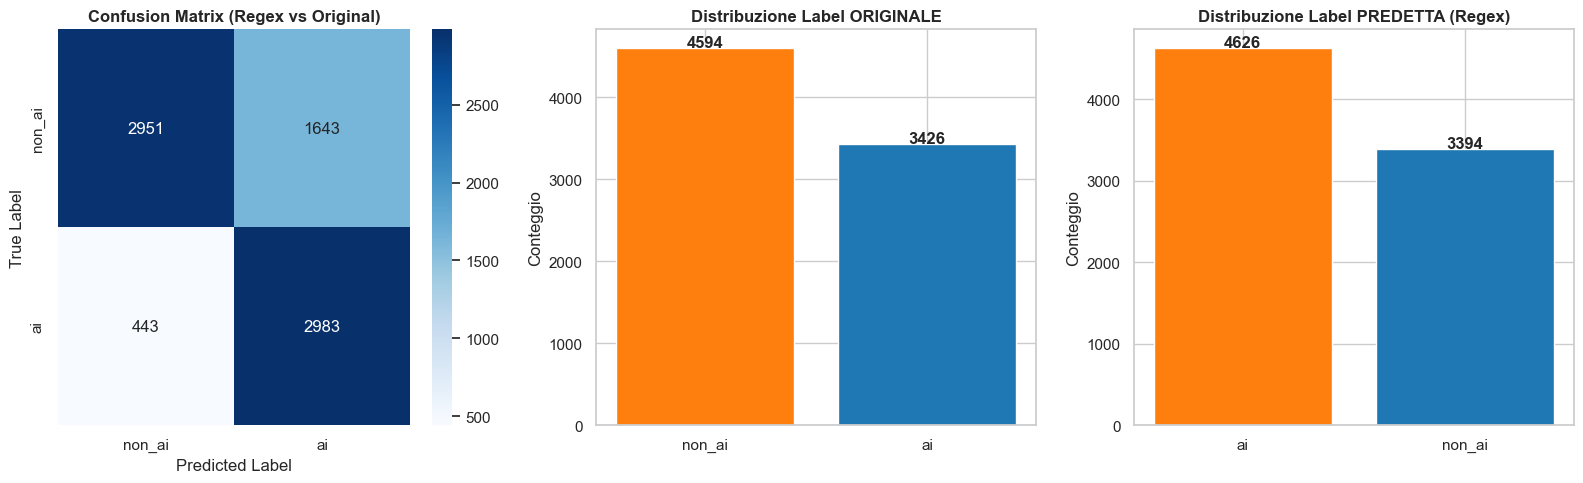

✓ Visualizzazioni generate


In [32]:
# Visualizzazione Confusion Matrix
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['non_ai', 'ai'], yticklabels=['non_ai', 'ai'],
            ax=axes[0], cbar=True)
axes[0].set_title('Confusion Matrix (Regex vs Original)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# 2. Distribuzione Label Originale
label_counts_orig = df['Label_original'].value_counts()
axes[1].bar(label_counts_orig.index, label_counts_orig.values, color=['#ff7f0e', '#1f77b4'])
axes[1].set_title('Distribuzione Label ORIGINALE', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Conteggio')
for i, v in enumerate(label_counts_orig.values):
    axes[1].text(i, v + 10, str(v), ha='center', fontweight='bold')

# 3. Distribuzione Label Predetta
label_counts_pred = df['Label_predicted'].value_counts()
axes[2].bar(label_counts_pred.index, label_counts_pred.values, color=['#ff7f0e', '#1f77b4'])
axes[2].set_title('Distribuzione Label PREDETTA (Regex)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Conteggio')
for i, v in enumerate(label_counts_pred.values):
    axes[2].text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Visualizzazioni generate")

## 6. Estrazione Top-20 Campioni per Categoria (TP, TN, FP, FN)

In [33]:
# Identificazione TP, TN, FP, FN
df['TP'] = (df['Label_original'] == 'ai') & (df['Label_predicted'] == 'ai')
df['TN'] = (df['Label_original'] == 'non_ai') & (df['Label_predicted'] == 'non_ai')
df['FP'] = (df['Label_original'] == 'non_ai') & (df['Label_predicted'] == 'ai')
df['FN'] = (df['Label_original'] == 'ai') & (df['Label_predicted'] == 'non_ai')

# Conteggi
print("=== CONTEGGI CATEGORIE ===")
print(f"TP (True Positive):   {df['TP'].sum():5d}")
print(f"TN (True Negative):   {df['TN'].sum():5d}")
print(f"FP (False Positive):  {df['FP'].sum():5d}")
print(f"FN (False Negative):  {df['FN'].sum():5d}")

# Estrazione top-20 per categoria
top_n = 20

print(f"\n### TOP-{top_n} TRUE POSITIVES (TP) ###")
tp_samples = df[df['TP']].head(top_n)[['Descrizione', 'Label_original', 'Label_predicted']]
display(tp_samples)

print(f"\n### TOP-{top_n} TRUE NEGATIVES (TN) ###")
tn_samples = df[df['TN']].head(top_n)[['Descrizione', 'Label_original', 'Label_predicted']]
display(tn_samples)

print(f"\n### TOP-{top_n} FALSE POSITIVES (FP) ###")
fp_samples = df[df['FP']].head(top_n)[['Descrizione', 'Label_original', 'Label_predicted']]
display(fp_samples)

print(f"\n### TOP-{top_n} FALSE NEGATIVES (FN) ###")
fn_samples = df[df['FN']].head(top_n)[['Descrizione', 'Label_original', 'Label_predicted']]
display(fn_samples)

=== CONTEGGI CATEGORIE ===
TP (True Positive):    2983
TN (True Negative):    2951
FP (False Positive):   1643
FN (False Negative):    443

### TOP-20 TRUE POSITIVES (TP) ###


,Descrizione,Label_original,Label_predicted
12,Implementazione sistemi di AI (artificial inte...,ai,ai
21,Horus è un sistema di Visual Recognition che r...,ai,ai
22,Innovativo apparato di visione artificiale a s...,ai,ai
45,L'attività di ricerca descritta nel presente d...,ai,ai
52,L'attività di ricerca che si intende effettuar...,ai,ai
85,E’ in carico a Generation Byte lo sviluppo dei...,ai,ai
89,L'attività di ricerca che si intende effettuar...,ai,ai
110,Sviluppo di un Software per l’interfacciamento...,ai,ai
116,Il progetto ha come obiettivo la messa a punto...,ai,ai
136,Acquisto Server per la domiciliazione e pubbli...,ai,ai



### TOP-20 TRUE NEGATIVES (TN) ###


,Descrizione,Label_original,Label_predicted
0,Concessione di agevolazioni sotto forma di ese...,non_ai,non_ai
1,Sostegno al'accesso al credito per finanziamen...,non_ai,non_ai
2,Concessione di agevolazioni sotto forma di ese...,non_ai,non_ai
3,Concessione di agevolazioni sotto forma di ese...,non_ai,non_ai
4,Concessione di agevolazioni sotto forma di ese...,non_ai,non_ai
5,Concessione di agevolazioni sotto forma di ese...,non_ai,non_ai
6,ALGORITMO RYLER,non_ai,non_ai
8,L Italia che ti sorprende,non_ai,non_ai
10,"Regione Lombardia, riconoscendo il teatro comp...",non_ai,non_ai
11,Analisi del rischio attraverso algoritmi matem...,non_ai,non_ai



### TOP-20 FALSE POSITIVES (FP) ###


,Descrizione,Label_original,Label_predicted
9,Machine Learning Solutions,non_ai,ai
23,Il progetto ha come scopo l’implementazione di...,non_ai,ai
35,Contenuto del progetto: come anticipato ai par...,non_ai,ai
42,MODELLO ORGANIZZATIVO AI SENSI DELL'ART. 30 D....,non_ai,ai
48,"""Il progetto di investimento prevede di “diver...",non_ai,ai
55,Brainive: Reti Neurali per la Sicurezza sui Lu...,non_ai,ai
59,MATICBOX - Intelligenza Artificiale per ottimi...,non_ai,ai
61,Intelligenza Artificiale e Bioinformatica a su...,non_ai,ai
68,Visione tramite Intelligenza Artificiale (VIA),non_ai,ai
69,AI4fit – Artificial Intelligence & Human Compu...,non_ai,ai



### TOP-20 FALSE NEGATIVES (FN) ###


,Descrizione,Label_original,Label_predicted
7,SVILUPPO DI UNA PROCEDURA AUTOMATIZZATA DI CAL...,ai,non_ai
17,Acquisizione di servizi innovativi per lo stud...,ai,non_ai
44,Il Protocollo Memo è frutto dello studio di a...,ai,non_ai
63,Il progetto CORYL ROBOT prevede la realizzazio...,ai,non_ai
79,ECOWELD+ è un rivoluzionario processo per la s...,ai,non_ai
86,"Attraverso il piano di intervento proposto, l ...",ai,non_ai
105,ECOWELD+ è un rivoluzionario processo per la s...,ai,non_ai
107,IL PIANO D'IMPRESA PREVEDE L'INDUSTRIALIZZAZIO...,ai,non_ai
123,L’idea progettuale si propone di rispondere al...,ai,non_ai
154,SVILUPPO DEL SOFTWARE DELLA PIATTAFORMA WEB DI...,ai,non_ai


## 7. Summary e Conclusioni

In [34]:
# Riepilogo metriche
summary_data = {
    'Metrica': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Valore': [accuracy, precision, recall, f1]
}
print("\n=== RIEPILOGO METRICHE ===")
print(pd.DataFrame(summary_data).to_string(index=False))

# Analisi errori
print("\n=== ANALISI ERRORI ===")
print(f"Totale FP (falsi positivi, etichettati 'ai' ma sono 'non_ai'): {fp}")
print(f"  → Questi potrebbero indicare false allarmi del regex pattern")
print(f"Totale FN (falsi negativi, etichettati 'non_ai' ma sono 'ai'): {fn}")
print(f"  → Questi potrebbero indicare termini AI non coperti dal pattern")

# Raccomandazioni
print("\n=== RACCOMANDAZIONI ===")
print("1. Se FP >> FN: il pattern è troppo aggressivo → ridurre i termini")
print("2. Se FN >> FP: il pattern è troppo conservativo → aggiungere termini")
print(f"3. F1-Score: {f1:.4f} ('ai' class balance tra Precision e Recall)")

# Salvataggio risultati completi (corretto il path)
output_path = Path('../../data/processed/regex_classification_results.csv')
output_path.parent.mkdir(parents=True, exist_ok=True)
df_export = df[['Descrizione', 'Label_original', 'Label_predicted', 'TP', 'TN', 'FP', 'FN']].copy()
df_export.to_csv(output_path, index=False)
print(f"\n✓ Risultati completi salvati in: {output_path}")

# Nuovo dataset con soli True Positive e True Negative
tp_tn_output_path = Path('../../data/processed/regex_classification_tp_tn.csv')
tp_tn_export = df.loc[df['TP'] | df['TN'], ['Descrizione', 'Label_predicted']].copy()
tp_tn_export.to_csv(tp_tn_output_path, index=False)
print(f"✓ Dataset TP/TN salvato in: {tp_tn_output_path} (righe: {len(tp_tn_export)})")


=== RIEPILOGO METRICHE ===
  Metrica   Valore
 Accuracy 0.739900
Precision 0.644834
   Recall 0.870695
 F1-Score 0.740934

=== ANALISI ERRORI ===
Totale FP (falsi positivi, etichettati 'ai' ma sono 'non_ai'): 1643
  → Questi potrebbero indicare false allarmi del regex pattern
Totale FN (falsi negativi, etichettati 'non_ai' ma sono 'ai'): 443
  → Questi potrebbero indicare termini AI non coperti dal pattern

=== RACCOMANDAZIONI ===
1. Se FP >> FN: il pattern è troppo aggressivo → ridurre i termini
2. Se FN >> FP: il pattern è troppo conservativo → aggiungere termini
3. F1-Score: 0.7409 ('ai' class balance tra Precision e Recall)

✓ Risultati completi salvati in: ..\..\data\processed\regex_classification_results.csv
✓ Dataset TP/TN salvato in: ..\..\data\processed\regex_classification_tp_tn.csv (righe: 5934)
✓ Dataset TP/TN salvato in: ..\..\data\processed\regex_classification_tp_tn.csv (righe: 5934)


## 8. Validazione Cross-Dataset: Regex + BERT

In [35]:
# Caricamento dei due dataset di origine
path_regex_tp_tn = Path('../../data/processed/regex_classification_tp_tn.csv')
path_bert = Path('../../data/training/bert_bin_unbiased_v2.csv')

df_regex = pd.read_csv(path_regex_tp_tn)
df_bert = pd.read_csv(path_bert)

print(f"✓ Dataset REGEX TP/TN: {df_regex.shape[0]} righe, {df_regex.shape[1]} colonne")
print(f"  Colonne: {list(df_regex.columns)}")
print(f"  Distribuzioni Label_predicted: {df_regex['Label_predicted'].value_counts().to_dict()}\n")

print(f"✓ Dataset BERT: {df_bert.shape[0]} righe, {df_bert.shape[1]} colonne")
print(f"  Colonne: {list(df_bert.columns)}")
print(f"  Distribuzioni label: {df_bert['label'].value_counts().to_dict()}")

print(f"\nPrime righe REGEX:")
display(df_regex.head(3))

print(f"\nPrime righe BERT:")
display(df_bert.head(3))


✓ Dataset REGEX TP/TN: 5934 righe, 2 colonne
  Colonne: ['Descrizione', 'Label_predicted']
  Distribuzioni Label_predicted: {'ai': 2983, 'non_ai': 2951}

✓ Dataset BERT: 15446 righe, 2 colonne
  Colonne: ['text', 'label']
  Distribuzioni label: {'NON AI': 7723, 'AI': 7723}

Prime righe REGEX:


,Descrizione,Label_predicted
0,Concessione di agevolazioni sotto forma di ese...,non_ai
1,Sostegno al'accesso al credito per finanziamen...,non_ai
2,Concessione di agevolazioni sotto forma di ese...,non_ai



Prime righe BERT:


,text,label
0,1. Analisi della soluzione e macro Stima 2.Spe...,NON AI
1,LÂ¿intero concetto di Impresa Digitale ruota i...,NON AI
2,LEILA una piattaforma di e-learning basata su ...,AI


### 8a. Applicazione Regex sul Dataset BERT

In [36]:
# Normalizzazione BERT dataset
df_bert['text_norm'] = df_bert['text'].fillna('').str.lower().str.strip()
df_bert['label_norm'] = df_bert['label'].str.lower().str.strip()

# Applicazione regex
df_bert['Label_predicted'] = df_bert['text_norm'].apply(predict_ai_by_regex)

# Mapping normalizzazione: 'NON AI' → 'non_ai', 'AI' → 'ai'
df_bert['label_norm_mapped'] = df_bert['label_norm'].map({'ai': 'ai', 'non ai': 'non_ai'})

print(f"✓ Regex applicata al dataset BERT")
print(f"\nDistribuzione etichette BERT ORIGINALI (normalizzate):")
print(df_bert['label_norm_mapped'].value_counts())
print(f"\nDistribuzione etichette BERT PREDETTE (Regex):")
print(df_bert['Label_predicted'].value_counts())

# Validazione: TP e TN nel BERT dataset
df_bert['TP'] = (df_bert['label_norm_mapped'] == 'ai') & (df_bert['Label_predicted'] == 'ai')
df_bert['TN'] = (df_bert['label_norm_mapped'] == 'non_ai') & (df_bert['Label_predicted'] == 'non_ai')
df_bert['FP'] = (df_bert['label_norm_mapped'] == 'non_ai') & (df_bert['Label_predicted'] == 'ai')
df_bert['FN'] = (df_bert['label_norm_mapped'] == 'ai') & (df_bert['Label_predicted'] == 'non_ai')

print(f"\n--- Validazione BERT con Regex ---")
print(f"TP: {df_bert['TP'].sum()}")
print(f"TN: {df_bert['TN'].sum()}")
print(f"FP: {df_bert['FP'].sum()}")
print(f"FN: {df_bert['FN'].sum()}")
print(f"Concordanza: {((df_bert['TP'] | df_bert['TN']).sum() / len(df_bert) * 100):.2f}%")


✓ Regex applicata al dataset BERT

Distribuzione etichette BERT ORIGINALI (normalizzate):
label_norm_mapped
non_ai    7723
ai        7723
Name: count, dtype: int64

Distribuzione etichette BERT PREDETTE (Regex):
Label_predicted
non_ai    8195
ai        7251
Name: count, dtype: int64

--- Validazione BERT con Regex ---
TP: 6261
TN: 6733
FP: 990
FN: 1462
Concordanza: 84.13%


### 8b. Metriche di Validazione Cross-Dataset

In [37]:
# === METRICHE DATASET REGEX TP/TN ===
print("="*60)
print("METRICHE DATASET REGEX (TP/TN - Gold Standard)")
print("="*60)

# Per regex dataset: Label_predicted vs Descrizione (già validato)
# TP: tutti hanno label_predicted='ai'
# TN: tutti hanno label_predicted='non_ai'
regex_tp_count = (df_regex['Label_predicted'] == 'ai').sum()
regex_tn_count = (df_regex['Label_predicted'] == 'non_ai').sum()

print(f"TP (AI):    {regex_tp_count}")
print(f"TN (NON AI): {regex_tn_count}")
print(f"Totale:     {len(df_regex)}")

# === METRICHE DATASET BERT ===
print("\n" + "="*60)
print("METRICHE DATASET BERT (Validazione con Regex)")
print("="*60)

y_true_bert = (df_bert['label_norm_mapped'] == 'ai').astype(int)
y_pred_bert = (df_bert['Label_predicted'] == 'ai').astype(int)

cm_bert = confusion_matrix(y_true_bert, y_pred_bert, labels=[0, 1])
tn_bert, fp_bert, fn_bert, tp_bert = cm_bert.ravel()

print(f"True Negatives (TN):  {tn_bert}")
print(f"False Positives (FP): {fp_bert}")
print(f"False Negatives (FN): {fn_bert}")
print(f"True Positives (TP):  {tp_bert}")

accuracy_bert = accuracy_score(y_true_bert, y_pred_bert)
precision_bert = precision_score(y_true_bert, y_pred_bert, zero_division=0)
recall_bert = recall_score(y_true_bert, y_pred_bert, zero_division=0)
f1_bert = f1_score(y_true_bert, y_pred_bert, zero_division=0)

print(f"\nAccuracy:  {accuracy_bert:.4f}")
print(f"Precision: {precision_bert:.4f}")
print(f"Recall:    {recall_bert:.4f}")
print(f"F1-Score:  {f1_bert:.4f}")

print(f"\n{classification_report(y_true_bert, y_pred_bert, target_names=['non_ai', 'ai'], zero_division=0)}")

# === CONFRONTO DATASETS ===
print("\n" + "="*60)
print("CONFRONTO COMPLESSIVO")
print("="*60)
print(f"Dataset REGEX TP/TN:    {len(df_regex):6d} righe (100% TP+TN)")
print(f"Dataset BERT Totale:    {len(df_bert):6d} righe")
print(f"  → TP+TN BERT:         {(tp_bert + tn_bert):6d} (Concordanza: {(tp_bert + tn_bert)/len(df_bert)*100:.2f}%)")
print(f"  → FP+FN BERT:         {(fp_bert + fn_bert):6d} (Discordanza: {(fp_bert + fn_bert)/len(df_bert)*100:.2f}%)")
print(f"\nDataset Merged Final:   {len(df_regex) + tp_bert + tn_bert:6d} righe (qualità garantita)")


METRICHE DATASET REGEX (TP/TN - Gold Standard)
TP (AI):    2983
TN (NON AI): 2951
Totale:     5934

METRICHE DATASET BERT (Validazione con Regex)
True Negatives (TN):  6733
False Positives (FP): 990
False Negatives (FN): 1462
True Positives (TP):  6261

Accuracy:  0.8413
Precision: 0.8635
Recall:    0.8107
F1-Score:  0.8362

              precision    recall  f1-score   support

      non_ai       0.82      0.87      0.85      7723
          ai       0.86      0.81      0.84      7723

    accuracy                           0.84     15446
   macro avg       0.84      0.84      0.84     15446
weighted avg       0.84      0.84      0.84     15446


CONFRONTO COMPLESSIVO
Dataset REGEX TP/TN:      5934 righe (100% TP+TN)
Dataset BERT Totale:     15446 righe
  → TP+TN BERT:          12994 (Concordanza: 84.13%)
  → FP+FN BERT:           2452 (Discordanza: 15.87%)

Dataset Merged Final:    18928 righe (qualità garantita)


### 8c. Top-20 Campioni TP e TN (Dataset REGEX)

In [41]:
# Mostra descrizioni complete nei dataframe stampati
pd.set_option('display.max_colwidth', None)

print("="*80)
print("TOP-20 TRUE POSITIVES (TP) - DATASET REGEX - Descrizioni Complete")
print("="*80)
tp_regex = df_regex[df_regex['Label_predicted'] == 'ai'][['Descrizione']].head(20).copy()
display(tp_regex)

print("\n\n" + "="*80)
print("TOP-20 TRUE NEGATIVES (TN) - DATASET REGEX - Descrizioni Complete")
print("="*80)
tn_regex = df_regex[df_regex['Label_predicted'] == 'non_ai'][['Descrizione']].head(20).copy()
display(tn_regex)


TOP-20 TRUE POSITIVES (TP) - DATASET REGEX - Descrizioni Complete


,Descrizione
10,Implementazione sistemi di AI (artificial intelligence) nella gestione ordine e fidelizzazione cliente (user) per la personalizzazione del Merchandising Youtuber / Social Page / Blogger
18,"Horus è un sistema di Visual Recognition che riesce ad identificare e classificare forme, colori e motivi di un\r\noggetto presente in un immagine. Il sistema analizza e codifica i pixel delle immagini identificando il colore, la forma/modello e il motivo/fantasia"
19,Innovativo apparato di visione artificiale a supporto della linea automatica di taglio mono-strato con testina mobile di tessuti in continuo “CRYSTAL”.
38,"L'attività di ricerca descritta nel presente documento intende proporre un approccio innovativo al controllo della qualità dei processi produttivi attraverso l'impiego di tecnologie avanzate di visione artificiale, intesa come strumento affidabile, efficace e, soprattutto, oggettivo con cui ""misurare"" i prodotti. L'idea alla base del progetto è lo sviluppo di un sistema di controllo intelligente dell'intera produzione in grado di analizzare la difettosità di processo con tempi di risposta estremamente ridotti e con la possibilità di correggere (anche in modalità automatica) in tempo reale eventuali anomalie di processo identificate come causa primaria di una determinata tipologia di anomalia rilevata sul prodotto. L'obiettivo finale del progetto è la progettazione e lo sviluppo di un sistema di visione artificiale facilmente trasportabile e flessibile, cioè adattabile rapidamente a diverse tipologie di processo o prodotto, che preveda l'utilizzo di telecamere e sensori ottici per l'acquisizione delle immagini dei prodotti in transito sulla linea, o a fine linea, e la ricerca automatica dei difetti geometrici ed estetici sul 100% della Produzione, in maniera oggettiva e sistematica,"
44,"L'attività di ricerca che si intende effettuare propone un approccio innovativo al controllo della qualità dei processi produttivi attraverso l'impiego di tecnologie avanzate di visione artificiale, intesa come strumento affidabile, efficace e, soprattutto, oggettivo con cui ""misurare"" i prodotti. L'idea alla base del progetto è lo sviluppo di un sistema di controllo intelligente in grado di individuare le difettosità del prodotto, sulla base di un ciclo di controllo e di caratteristiche predefinite. \r\nL'obiettivo finale del progetto è la progettazione e lo sviluppo di un sistema di visione artificiale facilmente trasportabile e flessibile, cioè adattabile rapidamente a diverse tipologie di controlli dei prodotti, che preveda l'utilizzo di telecamere e sensori ottici per l'acquisizione delle immagini dei prodotti soggetti a verifiche prima della spedizione, in maniera oggettiva e sistematica, svincolandosi dunque dalla soggettività dell'operatore che in molti casi ad oggi è colui che controlla, ne valuta l'accettabilità e le registra le anomalie."
69,"E’ in carico a Generation Byte lo sviluppo dei sistemi di integrazione necessari a centralizzare i dati provenienti dalle apparecchiature medicali. Si prevede l’implementazione di un sistema cibernetico come sistema di controllo a circuito chiuso basato su un motore a regole in “Fuzzy Logic”.\r\nSi prevede l’implementazione di reti neurali e sistemi di “Machine Learning” per lo studio, l’acquisizione dati e la modellazione del sistema “paziente” - “stazione di monitoraggio” - “attuatore somministrazione farmaci”.\r\nIl sistema ha come input i parametri rilevati, come output i parametri di somministrazione dei\r\nfarmaci e gli allarmi, il tutto conformemente a protocolli di cura clinici concordati."
71,"L'attività di ricerca che si intende effettuare propone un approccio innovativo al controllo della qualità dei processi produttivi attraverso l'impiego di tecnologie avanzate di visione artificiale, intesa come strumento affidabile, efficace e, soprattutto, oggettivo con cui ""misurare"" i prodotti. L'idea alla base del progetto è lo sviluppo di un sistema di controllo intel



TOP-20 TRUE NEGATIVES (TN) - DATASET REGEX - Descrizioni Complete


,Descrizione
0,Concessione di agevolazioni sotto forma di esenzioni fiscali e contributive in favore di imprese di micro e piccola dimensione localizz
1,Sostegno al'accesso al credito per finanziamenti a medio termine ed operazioni di leasing mediante l
2,Concessione di agevolazioni sotto forma di esenzioni fiscali e contributive in favore di imprese di micro e piccola dimensione localizzate nel terr
3,Concessione di agevolazioni sotto forma di esenzioni fiscali e contributive in favore di imprese di micro e piccola dimensione localizzat
4,Concessione di agevolazioni sotto forma di esenzioni fiscali e contributive in favore di imprese di micro e pi
5,Concessione di agevolazioni sotto forma di esenzioni fiscali e contributive in favore di imprese di micro e piccola dimensione localizzate nel territ
6,ALGORITMO RYLER
7,L Italia che ti sorprende
8,"Regione Lombardia, riconoscendo il teatro componente essenziale dei processi di promozione,\nsviluppo e diffusione della cultura, sostiene la produzione, la circuitazione e la fruizione per sviluppare e\nincrementare la partecipazione del pubblico alle attivita dello spettacolo sul territorio regionale.\nIl bando seleziona i soggetti con cui sottoscrivere convenzioni triennali 2015/2017 per il sostegno all attivita\ndi produzione teatrale e assegna i contributi per l anno 2015."
9,Analisi del rischio attraverso algoritmi matematici


### 8d. Top-20 Campioni TP e TN (Dataset BERT)

In [42]:
# Mostra descrizioni complete nei dataframe stampati
pd.set_option('display.max_colwidth', None)

print("="*80)
print("TOP-20 TRUE POSITIVES (TP) - DATASET BERT - Descrizioni Complete")
print("="*80)
tp_bert_samples = df_bert[df_bert['TP']][['text']].head(20).copy()
display(tp_bert_samples)

print("\n\n" + "="*80)
print("TOP-20 TRUE NEGATIVES (TN) - DATASET BERT - Descrizioni Complete")
print("="*80)
tn_bert_samples = df_bert[df_bert['TN']][['text']].head(20).copy()
display(tn_bert_samples)


TOP-20 TRUE POSITIVES (TP) - DATASET BERT - Descrizioni Complete


,text
2,LEILA una piattaforma di e-learning basata su AI generativa sui temi della Digital Transition Energy Transition e Health&pharma ed integra robotica mobile.
5,"adversarially robust training has been shown to reduce the susceptibility of learned models to targeted input data perturbations. however, it has also been observed that such adversarially robust models suffer a degradation in accuracy when applied to unperturbed data sets, leading to a robustness-accuracy tradeoff. inspired by recent progress in the adversarial machine learning literature which characterize such tradeoffs in simple settings, we develop tools to quantitatively study the performance-robustness tradeoff between nominal and robust state estimation. in particular, we define and analyze a novel $\textit{adversarially robust kalman filtering problem}$. we show that in contrast to most problem instances in adversarial machine learning, we can precisely derive the adversarial perturbation in the kalman filtering setting. we provide an algorithm to find this perturbation given data realizations, and develop upper and lower bounds on the adversarial state estimation error in terms of the standard (non-adversarial) estimation error and the spectral properties of the resulting observer. through these results, we show a natural connection between a filter's robustness to adversarial perturbation and underlying control theoretic properties of the system being observed, namely the spectral properties of its observability gramian."
7,"suicidal risk detection in adolescents is a critical challenge, yet existing methods rely on language-specific models, limiting scalability and generalization. this study introduces a novel language-agnostic framework for suicidal risk assessment with large language models (llms). we generate chinese transcripts from speech using an asr model and then employ llms with prompt-based queries to extract suicidal risk-related features from these transcripts. the extracted features are retained in both chinese and english to enable cross-linguistic analysis and then used to fine-tune corresponding pretrained language models independently. experimental results show that our method achieves performance comparable to direct fine-tuning with asr results or to models trained solely on chinese suicidal risk-related features, demonstrating its potential to overcome language constraints and improve the robustness of suicidal risk assessment."
8,Il progetto di innovazione SHAKE UP LAB prevede la digitalizzazione del processo di gestione delle attivit con l impiego di nuovi dispositivi elettronici dotati di intelligenza artificiale per l automazione e l aumento dell entertaiment ed engagement dei clienti. In particolare grazie all investimento in nuovi dispositivi aumentati videocamere videoproiettori altri dispositivi tecnici smartphone digital disply e software per la gestione delle immagini e dei video si potr digitalizzare l intero processo produttivo migliorandolo e attivando percorsi formativi virtuali. Al fine di potenziare l immagine dell azienda ed acquisire nuova clientela con lo sfruttamento delle tecnologie digitali prevediamo di realizzare un portale web e-commerce per la prenotazione on line dei servizi di Team Building e formazione oltre a una chat bot interattiva e automatizzata per l'infotainment dei clienti. A supporto della nuova soluzione tecnologica e digitale abbiamo intenzione di realizzare un intervento formativo qualificato del personale interno per la gestione ottimale del nuovo software e attivit di digital marketing.
10,Il progetto si focalizza sull'acquisizione e l'implementazione di una piattaforma software all'avanguardia per il Marketing Mix Modeling che sfrutta l'intelligenza artificiale per ottimizzare il processo produttivo di Webranking. L'adozione di questa soluzione apporter benefici significativi. In particolare si prevede un efficientamento del processo analitico grazie all'automazione delle attivit di data 



TOP-20 TRUE NEGATIVES (TN) - DATASET BERT - Descrizioni Complete


,text
0,1. Analisi della soluzione e macro Stima 2.Specifiche della soluzione -definizione dei requisiti 3.Design della soluzione -progettazione della soluzione software attuando dove necessario tecniche di â€œproto tipizzazioneâ€ 4.Sviluppo software della soluzione 5.Test della soluzione 6.Distribuzione della soluzione Il modello di SF di SiliconDev pertanto prevede i seguenti 6 â€˜hot topicsâ€™: La nostra Software Factorysi basa su una struttura â€œfunzionaleâ€ dedicata alla specializzazione e alla condivisione delle risorse nellâ€™ambito dei processi con lâ€™obiettivo di aumentare la produttivitÃ contenendo i costi di gestione.
1,LÂ¿intero concetto di Impresa Digitale ruota intorno a quella che viene chiamata Â¿rappresentazione informaticaÂ¿ e che puÃ² essere definita come il risultato della trasformazione in bit e successiva memorizzazione di quegli atti fatti o dati che possano avere rilevanza giuridica. La dematerializzazione dei documenti Ã¨ il processo attraverso cui il documento giuridico viene formato (e conservato) utilizzando supporti di natura telematica o piÃ¹ in generale informatica. Il documento Â¿dematerializzatoÂ¿ nel rispetto della normativa vigente ha il medesimo valore legale e probatorio del documento cartaceo (o analogico in genere). Il processo di dematerializzazione dei documenti quindi segna il passaggio dalla netta prevalenza del documento analogico ad un generale utilizzo del documento informatico. La dematerializzazione cosÃ¬ come disciplinata dal Codice investe sia i documenti che vengono creati direttamente in formato digitale sia le conversioni analogico/digitale (es. documenti originariamente creati in formato cartaceo e solo successivamente trasformati in documenti informatici) e riguarderÃ tutti i documenti inclusi quelli contabili di cui la legge impone la conservazione.
4,"PROGETTA E REALIZZA MACCHINE INDUSTRIALI, PRODUCE SISTEMI DI AUTOMAZIONE E DI INTEGRAZIONE ROBOTICA."
6,Lost in Plot sarÃ un servizio ad alto contenuto innovativo nellâ€™ambito dellâ€™industria del turismo culturale che proporrÃ a tutti gli interessati un nuovo modello di apprendimento esperienziale per conoscere e valorizzare il patrimonio culturale tangibile ed intangibile di un luogo condividendone le emozioni attraverso il gioco e la partecipazione attiva degli utenti (interattivitÃ della soluzione).
13,VERRA' REALIZZATA UNA SOLUZIONE E-COMMERCE E ACQUISTATI SOFTWARE PER LA GESTIONE DELLA FATTURAZIONE ON LINE/DIGITALE VERSO LA PUBBLICA AMMINISTRAZIONE E ALTRI PROGRAMMI SPECIALISTICI UTILI ALLA DIGITALIZZAZIONE DEI PROCESSI AZIENDALI.
15,Il progetto mira a migliorare la competitivitÃ della filiera del legno e la sostenibilitÃ dell'edilizia in legno attraverso l'innovazione tecnologica lâ€™analisi del ciclo di vita l'uso di materiali e processi piÃ¹ sostenibili e la formazione specializzata. Si realizzerÃ uno studio sull'applicazione di metamateriali realizzati in legno per la riduzione della propagazione della fiamma e per l'isolamento acustico applicato agli edifici multipiano in legno. Tale tecnologia innovativa permetterÃ al territorio interregionale di fornire una soluzione avanzata a questi due problemi molto presenti nell'edilizia in legno multipiano. Al fine di valorizzare la sostenibilitÃ dell'edilizia in legno attraverso l'analisi della filiera per valutare il ciclo di vita degli edifici si andranno a creare degli algoritmi iper-specializzati per gli edifici in legno facilitando in questo modo i processi di ecodesign. Riscontrata una carenza profonda di figure professionali specializzate nel settore dell'edilizia in legno la rete transfrontaliera di enti formativi e aziende svilupperÃ /adeguerÃ i percorsi formativi focalizzati sullâ€™edilizia multipiano in legno: la formazione fornirÃ al territorio interregionale figure specifiche che in questo momento sono mancanti.
16,Il progetto punta a digitalizzare ulteriormente l'azienda per migliorare l'efficienza dei servizi erogati migliorare il rapporto qualitÃ /te

## 9. Merge Training Dataset: TP/TN Pulito da REGEX + BERT

In [40]:
# === PREPARAZIONE DATASET 1: REGEX TP/TN ===
print("="*80)
print("PREPARAZIONE DATASET 1: REGEX TP/TN")
print("="*80)

df_regex_merged = df_regex.copy()
df_regex_merged.rename(columns={'Label_predicted': 'label'}, inplace=True)
df_regex_merged = df_regex_merged[['Descrizione', 'label']].copy()
df_regex_merged.rename(columns={'Descrizione': 'text'}, inplace=True)

print(f"Dataset REGEX preparato: {df_regex_merged.shape[0]} righe")
print(f"Colonne: {list(df_regex_merged.columns)}")
print(f"Distribuzioni label: {df_regex_merged['label'].value_counts().to_dict()}")

# === PREPARAZIONE DATASET 2: BERT TP/TN ONLY ===
print("\n" + "="*80)
print("PREPARAZIONE DATASET 2: BERT TP/TN ONLY")
print("="*80)

df_bert_tp_tn = df_bert[df_bert['TP'] | df_bert['TN']].copy()
df_bert_tp_tn['label_normalized'] = df_bert_tp_tn['Label_predicted']
df_bert_tp_tn = df_bert_tp_tn[['text', 'label_normalized']].copy()
df_bert_tp_tn.rename(columns={'label_normalized': 'label'}, inplace=True)

print(f"Dataset BERT TP/TN: {df_bert_tp_tn.shape[0]} righe")
print(f"Colonne: {list(df_bert_tp_tn.columns)}")
print(f"Distribuzioni label: {df_bert_tp_tn['label'].value_counts().to_dict()}")

# === MERGE FINALE ===
print("\n" + "="*80)
print("MERGE FINALE DEI DATASET")
print("="*80)

# Merge: REGEX prima (gold standard), poi BERT
df_training_final = pd.concat([df_regex_merged, df_bert_tp_tn], ignore_index=True)

print(f"Dataset Merged: {df_training_final.shape[0]} righe (REGEX: {len(df_regex_merged)} + BERT TP/TN: {len(df_bert_tp_tn)})")
print(f"Colonne finali: {list(df_training_final.columns)}")
print(f"\nDistribuzioni label FINALI:")
print(df_training_final['label'].value_counts())
print(f"\nPercentuali:")
print(df_training_final['label'].value_counts(normalize=True) * 100)

# Verificazione: nessun valore nullo
print(f"\nValori nulli: {df_training_final.isnull().sum().sum()} ✓")

# === SALVATAGGIO ===
print("\n" + "="*80)
print("SALVATAGGIO DATASET")
print("="*80)

output_merged_path = Path('../../data/processed/training_dataset_merged_tp_tn.csv')
output_merged_path.parent.mkdir(parents=True, exist_ok=True)
df_training_final.to_csv(output_merged_path, index=False)

print(f"✓ Dataset finale salvato in: {output_merged_path}")
print(f"  Righe: {len(df_training_final)}")
print(f"  Colonne: {list(df_training_final.columns)}")
print(f"\nPrime 5 righe:")
display(df_training_final.head())
print(f"\nUltime 5 righe:")
display(df_training_final.tail())


PREPARAZIONE DATASET 1: REGEX TP/TN
Dataset REGEX preparato: 5934 righe
Colonne: ['text', 'label']
Distribuzioni label: {'ai': 2983, 'non_ai': 2951}

PREPARAZIONE DATASET 2: BERT TP/TN ONLY
Dataset BERT TP/TN: 12994 righe
Colonne: ['text', 'label']
Distribuzioni label: {'non_ai': 6733, 'ai': 6261}

MERGE FINALE DEI DATASET
Dataset Merged: 18928 righe (REGEX: 5934 + BERT TP/TN: 12994)
Colonne finali: ['text', 'label']

Distribuzioni label FINALI:
label
non_ai    9684
ai        9244
Name: count, dtype: int64

Percentuali:
label
non_ai    51.162299
ai        48.837701
Name: proportion, dtype: float64

Valori nulli: 0 ✓

SALVATAGGIO DATASET
✓ Dataset finale salvato in: ..\..\data\processed\training_dataset_merged_tp_tn.csv
  Righe: 18928
  Colonne: ['text', 'label']

Prime 5 righe:


,text,label
0,Concessione di agevolazioni sotto forma di ese...,non_ai
1,Sostegno al'accesso al credito per finanziamen...,non_ai
2,Concessione di agevolazioni sotto forma di ese...,non_ai
3,Concessione di agevolazioni sotto forma di ese...,non_ai
4,Concessione di agevolazioni sotto forma di ese...,non_ai



Ultime 5 righe:


,text,label
18923,Il progetto migliora la competitivitÃ dell?az...,ai
18924,LA WEDOK SRL DA SEMPRE ATTIVA NELL INNOVAZIONE...,ai
18925,Ad oggi i controlli in field sullautenticitÃ ...,ai
18926,Fabbrica 4.0 per DR Meccanica:innovare il prod...,non_ai
18927,Realizzazione di un sito web con l'area di e-c...,non_ai


In [44]:
# Verifica unicità delle descrizioni nel dataset finale
unique_descriptions = df_training_final['text'].nunique(dropna=False)
total_rows = len(df_training_final)
duplicate_rows = total_rows - unique_descriptions

print("="*80)
print("VERIFICA UNICITA' DESCRIZIONI - DATASET FINALE")
print("="*80)
print(f"Righe totali: {total_rows}")
print(f"Descrizioni uniche: {unique_descriptions}")
print(f"Righe duplicate: {duplicate_rows}")

if duplicate_rows > 0:
    duplicate_counts = df_training_final['text'].value_counts()
    duplicate_examples = duplicate_counts[duplicate_counts > 1].head(10)
    print("\nPrime descrizioni duplicate:")
    display(duplicate_examples.to_frame(name='conteggio'))
else:
    print("\nIl dataset finale contiene descrizioni tutte uniche.")


VERIFICA UNICITA' DESCRIZIONI - DATASET FINALE
Righe totali: 18928
Descrizioni uniche: 18305
Righe duplicate: 623

Prime descrizioni duplicate:


,conteggio
text,
1.Acquisire capacitÃ tecnico-pratiche di utilizzo delle tecnologie digitali di Building Information Modeling attraverso il sw Autodesk Revit per lo studio la preparazione l'analisi la progettazione grafica e la gestione di un progetto AEC (Architecture Engineering & Construction),5
Realizzazione di un prototipo di diserbo combinato che sfrutta l'intelligenza artificiale.,4
Realizzare un prototipo modulare subacqueo con algoritmi di IA e ML per monitorare i rifiuti marini.,4
sviluppo e produzione di un innovativo software applicativo basato su intelligenza artificiale e deep machine learning per la produzione di test per la valutazione dello stato cognitivo,4
Il progetto in oggetto ha come obiettivo l'aggiunta dell' AI Generativa per la creazione dei report automatici e degli insight per i manager dei processi e per il miglioramento delle analitiche grazie all'apporto dell'AI.,4
SVILUPPO DI TECNOLOGIE BASATE SU METODI DI INTELLIGENZA ARTIFICIALE PER IL RILASCIO CONTROLLATO DI FARMACI A BASE PEPTIDICA,4
Soluzione innovativa di Machine Learning e analisi dati di funzionamento di asset connessi per identificare elementi non espliciti di user experience per migliorare e ottimizzare la progettazione del prodotto e feedback predittivi sul processo industriale,4
Sviluppo di un ambiente di supporto alla ricerca biomedica: analisi dati multimodali e clinici con l'ausilio dell'intelligenza artificiale,4
Evoluzione digitale di una piattaforma industriale per la connessione e analisi dati di macchine/giostre in ottica di machine learning & Digital Twin,4


In [46]:
# Salvataggio versione deduplicata del dataset finale
df_training_final_dedup = df_training_final.drop_duplicates(subset=['text'], keep='first').copy()

output_merged_dedup_path = Path('../../data/processed/training_dataset_merged_tp_tn_deduplicated.csv')
df_training_final_dedup.to_csv(output_merged_dedup_path, index=False)

print("="*80)
print("SALVATAGGIO DATASET DEDUPLICATO")
print("="*80)
print(f"Righe originali: {len(df_training_final)}")
print(f"Righe deduplicate: {len(df_training_final_dedup)}")
print(f"Righe rimosse: {len(df_training_final) - len(df_training_final_dedup)}")
print(f"Descrizioni uniche: {df_training_final_dedup['text'].nunique(dropna=False)}")
print(f"Valori nulli: {df_training_final_dedup.isnull().sum().sum()}")
print(f"\n✓ Dataset deduplicato salvato in: {output_merged_dedup_path}")
print(f"Colonne finali: {list(df_training_final_dedup.columns)}")
print(f"\nDistribuzioni label dopo deduplica:")
print(df_training_final_dedup['label'].value_counts())


SALVATAGGIO DATASET DEDUPLICATO
Righe originali: 18928
Righe deduplicate: 18305
Righe rimosse: 623
Descrizioni uniche: 18305
Valori nulli: 0

✓ Dataset deduplicato salvato in: ..\..\data\processed\training_dataset_merged_tp_tn_deduplicated.csv
Colonne finali: ['text', 'label']

Distribuzioni label dopo deduplica:
label
non_ai    9635
ai        8670
Name: count, dtype: int64
